# Notebook 2: Baseline Embeddings

**Goal:** Establish a baseline using pretrained sentence-transformer embeddings with the default text representation. Compare against a TF-IDF baseline.

**Research question:** How well do pretrained text embeddings capture food preferences compared to keyword-based (TF-IDF) retrieval?

**Evaluation protocol:** Item-to-item co-preference — for each test user, take one ordered dish as query, measure how many of their other ordered dishes appear in top-K results.

In [1]:
# ============================================================
# SETUP
# ============================================================
import os, sys

REPO = "Embedding-Based-Recommender"
GITHUB_USER = "IldarRakiev"

ENV = 'kaggle' if os.path.exists('/kaggle/working') else 'colab'
BASE = '/kaggle/working' if ENV == 'kaggle' else '/content'
REPO_DIR = f'{BASE}/{REPO}'

if not os.path.exists(REPO_DIR):
    os.system(f'git clone https://github.com/{GITHUB_USER}/{REPO}.git {REPO_DIR}')
else:
    os.system(f'cd {REPO_DIR} && git pull -q')

os.system('pip install -q sentence-transformers faiss-cpu pandas pyarrow matplotlib seaborn umap-learn plotly scikit-learn tqdm')
sys.path.insert(0, f'{REPO_DIR}/src')
print(f"Environment: {ENV} | Repo: {REPO_DIR}")
print("Setup complete")

Cloning into '/kaggle/working/Embedding-Based-Recommender'...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 72.5 MB/s eta 0:00:00
Environment: kaggle | Repo: /kaggle/working/Embedding-Based-Recommender
Setup complete


In [2]:
# ============================================================
# DATA PATHS
# ============================================================
import os, glob as _glob

ENV = 'kaggle' if os.path.exists('/kaggle/working') else 'colab' if os.path.exists('/content') else 'local'

if ENV == 'local':
    SYNTHETIC_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data', 'synthetic')
else:
    SYNTHETIC_DIR = os.path.join(REPO_DIR, 'data', 'synthetic')

OUTPUT_DIR = '/kaggle/working/processed' if ENV == 'kaggle' else SYNTHETIC_DIR
os.makedirs(OUTPUT_DIR, exist_ok=True)

assert os.path.exists(SYNTHETIC_DIR), f"Synthetic data not found: {SYNTHETIC_DIR}"
print(f"SYNTHETIC_DIR = {SYNTHETIC_DIR}")
print(f"OUTPUT_DIR    = {OUTPUT_DIR}")

SYNTHETIC_DIR = /kaggle/working/Embedding-Based-Recommender/data/synthetic
OUTPUT_DIR    = /kaggle/working/processed


In [3]:
from text_builders import dish_to_rich_text
from embedding_model import EmbeddingModel
from utils import evaluate_all, plot_embeddings_umap, plot_nearest_neighbors
import pandas as pd
import numpy as np
np.random.seed(42)

In [4]:
import pandas as pd
import numpy as np
np.random.seed(42)

dishes = pd.read_parquet(f'{SYNTHETIC_DIR}/dishes.parquet')
train = pd.read_parquet(f'{SYNTHETIC_DIR}/interactions_train.parquet')
test = pd.read_parquet(f'{SYNTHETIC_DIR}/interactions_test.parquet')

print(f"Dishes: {len(dishes):,} | Train: {len(train):,} | Test: {len(test):,}")
print(f"Interaction types in test: {test['interaction_type'].value_counts().to_dict()}")

Dishes: 4,939 | Train: 117,449 | Test: 39,150
Interaction types in test: {'view': 27546, 'order': 6093, 'rating': 4194, 'favorite': 1317}


## 1. Build Baseline Dish Texts

We use `dish_to_rich_text()` with **default flags** (baseline configuration):
- `include_recipe=True` — recipe instructions included
- `include_macro_tokens=True` — discrete HIGH_PROTEIN/LOW_FAT tokens included
- `include_ratios=False` — no continuous ratios
- `include_ingredients=False` — no extracted ingredient list

In [5]:
# Build texts with baseline defaults (all flags at default)
texts = []
dish_id_to_idx = {}
idx_to_dish_id = {}

for i, (_, row) in enumerate(dishes.iterrows()):
    text = dish_to_rich_text(
        row.to_dict(),
        tags=row.get('tag_list', []),
        # All flags at default = baseline
    )
    texts.append(text)
    dish_id_to_idx[row['id']] = i
    idx_to_dish_id[i] = row['id']

print(f"Built {len(texts):,} texts")
print("\n=== Example text (index 0) ===")
print(texts[0][:500])

Built 4,939 texts

=== Example text (index 0) ===
DISH_NAME: Kholodets
DESCRIPTION: Kholodets is a traditional chilled meat jelly that is rich and savory, typically served as an appetizer. Its unique texture and gelatinous consistency are balanced by the flavors of seasoned meat and aromatic spices.
NUTRITION: 150 kcal, 20g protein, 7g fat, 1g carbs, 0g fiber
MACRO_TAGS: MEDIUM_PROTEIN LOW_FAT LOW_CARB PROTEIN_DOMINANT LOW_CALORIE
TAGS: savory traditional gelatinous
RECIPE_BRIEF: 1. In a large pot, combine 1 kg of pork shank, 500 g of beef, 3 l


## 2. Generate Embeddings & Build FAISS Index

In [6]:
import faiss

print("Loading embedding model...")
model = EmbeddingModel()  # paraphrase-multilingual-mpnet-base-v2, 768-dim
print(f"Model: {model.model_name} | dim={model.dim}")

print("\nEncoding texts...")
embeddings = model.encode(texts)  # shape: (N, 768), L2-normalized
print(f"Embeddings: {embeddings.shape} | {embeddings.nbytes / 1e6:.1f} MB")

# FAISS IndexFlatIP = exact cosine similarity (vectors are already normalized)
index = faiss.IndexFlatIP(model.dim)
index.add(embeddings)
print(f"FAISS index built: {index.ntotal:,} vectors")

Loading embedding model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model: paraphrase-multilingual-mpnet-base-v2 | dim=768

Encoding texts...


Batches:   0%|          | 0/78 [00:00<?, ?it/s]

Embeddings: (4939, 768) | 15.2 MB
FAISS index built: 4,939 vectors


## 3. Evaluation Protocol: Item-to-Item Co-Preference

Since we have explicit orders (not just ratings), we define positives as:
- `interaction_type == 'order'` — user actually ordered this dish
- `interaction_type == 'favorite'` — user explicitly saved it

**Protocol:**
1. For each test user with ≥5 positive interactions (orders/favorites)
2. Take one positive dish as the **query**
3. User's remaining positive dishes = **relevant set**
4. Search FAISS for top-K neighbors of query
5. Measure: how many top-K results are in the relevant set?

In [7]:
def evaluate_retrieval(index, embeddings, ks=None, min_positives=5):
    """Evaluate retrieval via item-to-item co-preference protocol."""
    if ks is None:
        ks = [5, 10, 20]

    # Positives = orders + favorites
    user_positives = (
        test[test['interaction_type'].isin(['order', 'favorite'])]
        .groupby('user_id')['dish_id']
        .apply(set)
        .to_dict()
    )

    results = []
    for user_id, pos_dishes in user_positives.items():
        pos_dishes = {d for d in pos_dishes if d in dish_id_to_idx}
        if len(pos_dishes) < min_positives:
            continue

        pos_list = list(pos_dishes)
        query_dish = pos_list[0]
        relevant = pos_dishes - {query_dish}

        query_idx = dish_id_to_idx[query_dish]
        scores, indices = index.search(embeddings[query_idx:query_idx+1], max(ks) + 1)

        recommended = [
            idx_to_dish_id[i]
            for i in indices[0]
            if i >= 0 and idx_to_dish_id.get(i) != query_dish
        ]

        metrics = evaluate_all(recommended, relevant, ks=ks)
        results.append(metrics)

    if not results:
        return {}, 0

    metrics = pd.DataFrame(results).mean().to_dict()
    return metrics, len(results)


print("Evaluating baseline embedding...")
baseline_metrics, n_eval_users = evaluate_retrieval(index, embeddings)
print(f"\nBaseline Embedding Metrics (n_users={n_eval_users}):")
for k, v in sorted(baseline_metrics.items()):
    print(f"  {k}: {v:.4f}")

Evaluating baseline embedding...

Baseline Embedding Metrics (n_users=758):
  HR@10: 0.0158
  HR@20: 0.0251
  HR@5: 0.0066
  MRR: 0.0032
  NDCG@10: 0.0015
  NDCG@20: 0.0022
  NDCG@5: 0.0010
  P@10: 0.0016
  P@20: 0.0013
  P@5: 0.0013
  R@10: 0.0020
  R@20: 0.0038
  R@5: 0.0009


## 4. TF-IDF Baseline Comparison

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import scipy.sparse as sp

print("Fitting TF-IDF...")
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(texts)
print(f"TF-IDF matrix: {tfidf_matrix.shape}")

svd = TruncatedSVD(n_components=256, random_state=42)
tfidf_dense = svd.fit_transform(tfidf_matrix).astype(np.float32)
faiss.normalize_L2(tfidf_dense)

tfidf_index = faiss.IndexFlatIP(256)
tfidf_index.add(tfidf_dense)

print("Evaluating TF-IDF + SVD...")
tfidf_metrics, _ = evaluate_retrieval(tfidf_index, tfidf_dense)


def _metric_dict(m):
    """evaluate_retrieval возвращает (dict, n); если забыли распаковать — берём [0]."""
    return m[0] if isinstance(m, tuple) and len(m) and isinstance(m[0], dict) else m

comparison = pd.concat(
    {
        "TF-IDF + SVD(256)": pd.Series(_metric_dict(tfidf_metrics), name="TF-IDF + SVD(256)"),
        "Pretrained Embedding": pd.Series(_metric_dict(baseline_metrics), name="Pretrained Embedding"),
    },
    axis=1,
)
comparison = comparison.astype(float)
print("\n=== Comparison ===")
print(comparison.round(4))

Fitting TF-IDF...
TF-IDF matrix: (4939, 20000)
Evaluating TF-IDF + SVD...

=== Comparison ===
         TF-IDF + SVD(256)  Pretrained Embedding
P@5                 0.0016                0.0013
R@5                 0.0014                0.0009
NDCG@5              0.0013                0.0010
HR@5                0.0079                0.0066
P@10                0.0020                0.0016
R@10                0.0034                0.0020
NDCG@10             0.0024                0.0015
HR@10               0.0198                0.0158
P@20                0.0015                0.0013
R@20                0.0047                0.0038
NDCG@20             0.0030                0.0022
HR@20               0.0290                0.0251
MRR                 0.0048                0.0032


## 5. Nearest Neighbor Sanity Check

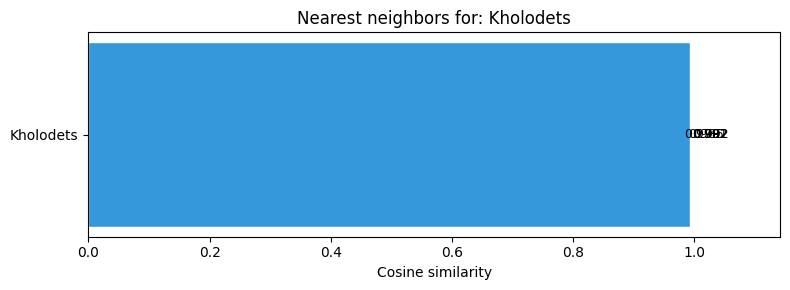

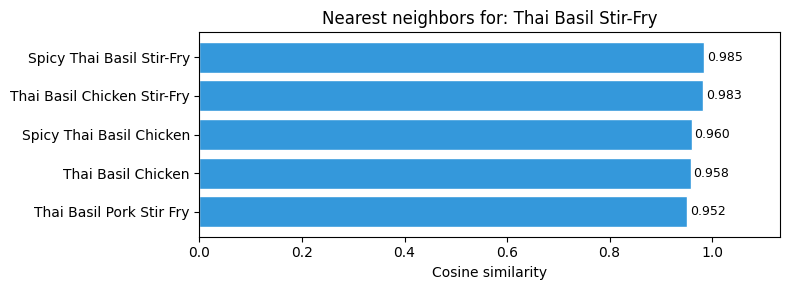

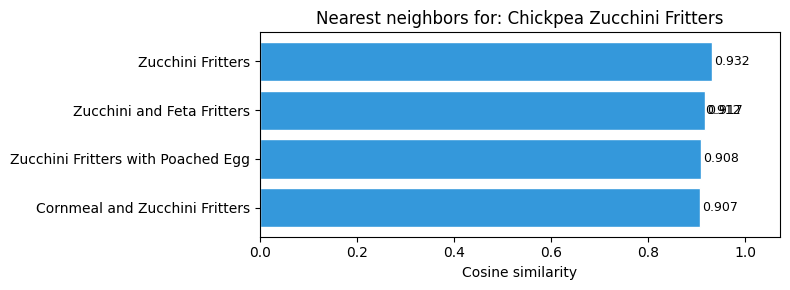

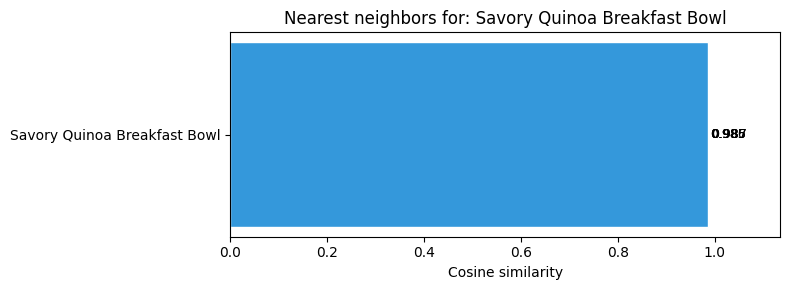

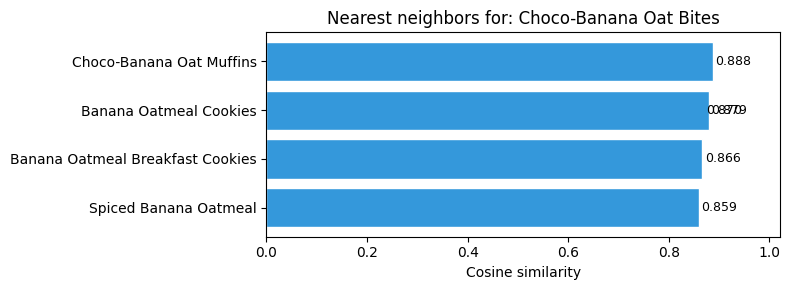

In [9]:
id_to_name = dict(zip(dishes['id'], dishes['name']))

# Pick 5 diverse query dishes from different clusters
CLUSTER_NAMES = {0:'Russian/Slavic',1:'Mediterranean',2:'Asian',3:'American',4:'Healthy/Diet',5:'Comfort/Hearty',6:'Breakfast',7:'Desserts/Snacks'}
query_dishes = []
for cluster_id in [0, 2, 4, 6, 7]:
    sample = dishes[dishes['cuisine_cluster'] == cluster_id].iloc[0]
    query_dishes.append((sample['id'], sample['name']))

for query_id, query_name in query_dishes:
    query_idx = dish_id_to_idx.get(query_id)
    if query_idx is None:
        continue

    scores, indices = index.search(embeddings[query_idx:query_idx+1], 6)
    neighbor_names = [id_to_name.get(idx_to_dish_id.get(i), '?') for i in indices[0][1:]]
    neighbor_scores = scores[0][1:].tolist()

    plot_nearest_neighbors(
        query_name=query_name,
        neighbor_names=neighbor_names,
        scores=neighbor_scores,
    )

## 6. UMAP Visualization

2026-04-13 19:57:56.138306: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776110276.365567      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776110276.421672      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776110276.868453      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776110276.868496      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776110276.868499      24 computation_placer.cc:177] computation placer alr

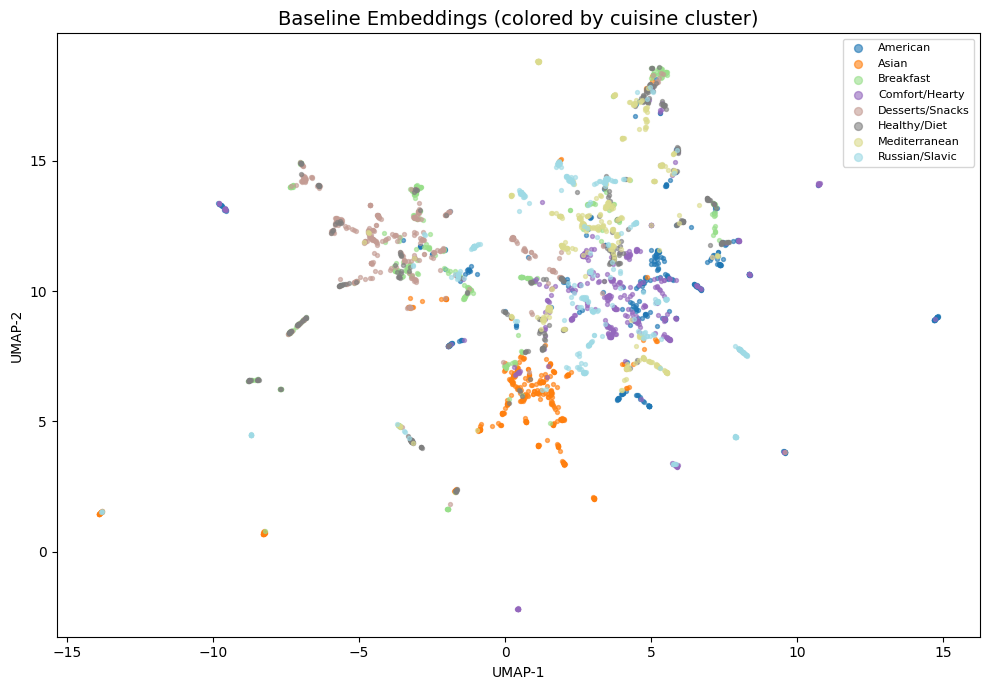

In [10]:
SAMPLE = 3000
sample_idx = np.random.choice(len(embeddings), SAMPLE, replace=False)
sample_embs = embeddings[sample_idx]

# Color by cuisine cluster
sample_ids = [idx_to_dish_id[i] for i in sample_idx]
id_to_cluster = dict(zip(dishes['id'], dishes['cuisine_cluster']))
labels = [CLUSTER_NAMES.get(id_to_cluster.get(rid, -1), 'other') for rid in sample_ids]

plot_embeddings_umap(sample_embs, labels, title='Baseline Embeddings (colored by cuisine cluster)')

In [11]:
import json
all_results = {
    'tfidf_svd': tfidf_metrics,
    'baseline_embedding': baseline_metrics,
}
with open(f'{OUTPUT_DIR}/results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

np.save(f'{OUTPUT_DIR}/embeddings_baseline.npy', embeddings)
print("✓ Results and embeddings saved to", OUTPUT_DIR)

✓ Results and embeddings saved to /kaggle/working/processed
